In [ ]:
import os
import argparse
from datetime import datetime

from typing import List, Tuple

import glob
import sys

sys.path.append('../..')

import torch

from neuralop.models import FNO
# from muno.models.fno import FNO

from muno.utils.training_utils import load_files_hdf5, validateOperator

from muno.utils.domains import Domain
from muno.utils.data_utils import SimpleDataset, NDDataset
from muno.utils.custom_trainer import Trainer, Logger

from muno.models.pecoda import PeCODANO
from muno.models.mamba_fno import PostLiftMambaFNO3D, PostLiftMambaLifting

from muno.models.localattn_exp import LocalAttnFNO

from muno.data import UnitGaussianNormalizer
from muno.data.data.transforms.data_processors import DefaultDataProcessor

from neuralop.layers.channel_mlp import ChannelMLP

import xarray as xr
from torch.nn import MSELoss


Imported correct mamba


In [1]:
import torch

def vrmse(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-8):
    return torch.sqrt(torch.mean(torch.pow(pred - target, 2)) /
                      (torch.mean(torch.pow(target - torch.mean(target), 2)) + eps))

In [8]:
a = torch.normal(torch.full((10, 10), 0.), torch.full((10, 10), 1.))
# print(a)
print(vrmse(torch.full_like(a, torch.mean(a)), a))

tensor(1.)


In [2]:
import torch.nn as nn

MAMBA_AVAILABLE = False
MambaClass = None
try:
    import mamba_ssm as mamba_pkg
    if hasattr(mamba_pkg, "Mamba"):
        MambaClass = mamba_pkg.Mamba
        MAMBA_AVAILABLE = True
except Exception:
    try:
        from mamba import Mamba as MambaClass
        MAMBA_AVAILABLE = True
    except Exception:
        MAMBA_AVAILABLE = False

class SimpleSSM(nn.Module):
    def __init__(self, dim, kernel_size=9):
        super().__init__()
        pad = (kernel_size - 1) // 2
        self.dw = nn.Conv1d(dim, dim, kernel_size=kernel_size, padding=pad, groups=dim, bias=True)
        self.gate = nn.Conv1d(dim, dim, kernel_size=1)
        self.norm = nn.LayerNorm(dim)
        nn.init.xavier_uniform_(self.dw.weight)
        nn.init.zeros_(self.dw.bias)
        nn.init.xavier_uniform_(self.gate.weight)
        nn.init.zeros_(self.gate.bias)

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        y = self.dw(x_t)
        y = torch.tanh(y)
        g = torch.sigmoid(self.gate(x_t))
        out = (1 - g) * x_t + g * y
        out = out.permute(0, 2, 1)
        return self.norm(out)

In [3]:
class PostLiftMambaProcessor3D(nn.Module):
    """
    Apply SSM across spatial dimensions (H and W) for each time slice.
    Input: [B, C, H, W, T] → process each (H, W) plane independently per time.
    """
    def __init__(self, hidden_channels, mamba_kwargs=None, fallback_kernel=9):
        super().__init__()
        self.C = hidden_channels
        self.mamba_kwargs = mamba_kwargs or {}
        self._use_mamba = False

        if MAMBA_AVAILABLE and MambaClass is not None:
            # print('HEREEEEE')
            try:
                self.ssm = MambaClass(d_model=self.C, d_state=self.C, d_conv=2, **self.mamba_kwargs)
                self._use_mamba = True
            except Exception:
                try:
                    self.ssm = MambaClass(self.C)
                    self._use_mamba = True
                except Exception:
                    self.ssm = SimpleSSM(dim=self.C, kernel_size=fallback_kernel)
                    self._use_mamba = False
        else:
            self.ssm = SimpleSSM(dim=self.C, kernel_size=fallback_kernel)
            self._use_mamba = False

        self.norm = nn.LayerNorm(self.C)

    def forward(self, x_lift):
        """
        x_lift: [B, C, H, W, T]
        Process each (H, W) spatial plane per time step.
        """
        B, C, T, H, W = x_lift.shape
        # print(f'x_lift shape: B {B}, C {C}, H {H}, W {W}, T {T}')

        assert C == self.C

        # Flatten spatial dims: [B*T, H*W, C]
        tokens = x_lift.permute(0, 2, 3, 4, 1).contiguous().view(B, T * H * W, C)

        if self._use_mamba:
            try:
                out = self.ssm(tokens)
            except Exception:
                try:
                    out_tmp = self.ssm(tokens.permute(0, 2, 1))
                    out = out_tmp.permute(0, 2, 1)
                except Exception:
                    out = self.ssm(tokens)
        else:
            out = self.ssm(tokens)

        out = self.norm(out)
        # out = out.view(B, T, H, W, C)
        # print('out.shape before view', B, T, H, W, C, out.shape)
        out = out.view(B, T, H, W, C).permute(0, 4, 1, 2, 3).contiguous()
        # print('out.shape', out.shape)
        return out

In [4]:
class PostLiftMambaFNO3D(FNO):
    def __init__(self, in_channels=5, out_channels=2, modes=(32, 32, 16), width=32, n_layers=4,
                 use_mamba_kwargs=None, mamba_fallback_kernel=9):
        super().__init__(
            n_modes=modes,
            hidden_channels=width,
            in_channels=in_channels,      # u0(2) + f(1) + x(1) + y(1)
            out_channels=out_channels,
            factorization='tucker',
            rank=0.05,
            implementation='factorized',
            n_layers=n_layers,
            use_channel_mlp = True,
            channel_mlp_dropout = 0.1,
            positional_embedding=None
        )
        self.post_lift_ssm = PostLiftMambaProcessor3D(
            hidden_channels=width,
            mamba_kwargs=use_mamba_kwargs,
            fallback_kernel=mamba_fallback_kernel
        )

    def forward(self, x):
        # Standard FNO pipeline
        if self.positional_embedding is not None:
            # print(x.shape)
            x = self.positional_embedding(x)
        x = self.lifting(x)
        if self.domain_padding is not None:
            x = self.domain_padding.pad(x)

        # Apply Mamba/SSM after lifting
        x = self.post_lift_ssm(x)  # [B, C, H, W, T]

        for layer_idx in range(self.n_layers):
            x = self.fno_blocks(x, layer_idx)
        if self.domain_padding is not None:
            x = self.domain_padding.unpad(x)
        x = self.projection(x)
        return x

In [ ]:
from muno.models.local_no import LocalNO
import warnings

class PostLiftMambaLNO3D(LocalNO):
    def __init__(self, in_channels=5, out_channels=2, modes=(32, 32, 16), width=32, n_layers=4, 
                 radius_cutoff = 1e-2, in_shape: tuple = (8, 8),
                 use_mamba_kwargs=None, mamba_fallback_kernel=9):
        super().__init__(
            n_modes=modes,
            hidden_channels=width,
            in_channels=in_channels,
            out_channels=out_channels,
            factorization='tucker', # ,None
            rank=0.05,
            implementation='factorized',
            n_layers=n_layers,
            use_channel_mlp = True,
            channel_mlp_dropout = 0.1,
            positional_embedding=None,
            default_in_shape=in_shape,
            # default_in_shape = in_shape,
            radius_cutoff = radius_cutoff
        )
        self.post_lift_ssm = PostLiftMambaProcessor3D(
            hidden_channels=width,
            mamba_kwargs=use_mamba_kwargs,
            fallback_kernel=mamba_fallback_kernel
        )

    def forward(self, x, output_shape=None, **kwargs):
        if kwargs:
            warnings.warn(
                f"LocalNO.forward() received unexpected keyword arguments: {list(kwargs.keys())}. "
                "These arguments will be ignored.",
                UserWarning,
                stacklevel=2,
            )

        if output_shape is None:
            output_shape = [None] * self.n_layers
        elif isinstance(output_shape, tuple):
            output_shape = [None] * (self.n_layers - 1) + [output_shape]

        # append spatial pos embedding if set
        if self.positional_embedding is not None:
            x = self.positional_embedding(x)

        x = self.lifting(x)

        if self.domain_padding is not None:
            x = self.domain_padding.pad(x)

        # Apply Mamba/SSM after lifting
        x = self.post_lift_ssm(x)  # [B, C, H, W, T]            

        for layer_idx in range(self.n_layers):
            x = self.local_no_blocks(x, layer_idx, output_shape=output_shape[layer_idx])

        if self.domain_padding is not None:
            x = self.domain_padding.unpad(x)

        x = self.projection(x)

        return x

In [6]:
# model_name = '/home/mikemaslyaev/Documents/FNOFound/experiments/pretrained_models/current_postlift_mamba_NO.pt'
model_name = '/home/mikemaslyaev/Documents/gpn/current_postlift_mamba_NO.pt'
# model_name = '/home/mikemaslyaev/Documents/gpn/current_postlift_mamba_ns.pt'
# '/home/mikemaslyaev/Documents/gpn/current_postlift_mamba_NO.pt' #'/home/mikemaslyaev/Documents/FNOFound/experiments/pretrained_models/flows_fno_6_10_35.pt'
model_dict = torch.load(model_name, map_location="cuda")

LNO = False

# try:
# model = PostLiftMambaFNO3D(
#     in_channels=3, 
#     out_channels=2,
#     modes = (6, 20, 20), #modes=(6, 40, 40),
#     width=32,
#     n_layers=4
# ).to('cuda')

# model = FNO(in_channels=3,
#             out_channels=2,
#             n_modes=(12, 70, 70),
#             hidden_channels=32,
#             # factorization='tucker',
#             # rank=0.05,
#             # implementation='factorized',
#             use_channel_mlp = True,
#             channel_mlp_dropout = 0.1,
#             positional_embedding=None,               
#             n_layers=4).to('cuda')
# model.load_state_dict(model_dict)

# except:
#     if LNO:
model = PostLiftMambaLNO3D(in_channels=3,
                            out_channels=2,
                            modes=(6, 30, 30),
                            in_shape = (128, 128),
                            width=30,
                            n_layers=4,
                            radius_cutoff = 0.1).to('cuda')
#     else:
#         model = PostLiftMambaFNO3D(in_channels=3,
#                                    out_channels=2,
#                                    modes=(6, 90, 90),
#                                    width=32,
#                                    n_layers=4).to('cuda')

/tmp/ipykernel_613278/3476653326.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(model_name, map_location="cuda")


In [7]:
model_dict.keys()

odict_keys(['local_no_blocks.convs.0.bias', 'local_no_blocks.convs.0.weight.core', 'local_no_blocks.convs.0.weight.factors.factor_0', 'local_no_blocks.convs.0.weight.factors.factor_1', 'local_no_blocks.convs.0.weight.factors.factor_2', 'local_no_blocks.convs.0.weight.factors.factor_3', 'local_no_blocks.convs.0.weight.factors.factor_4', 'local_no_blocks.convs.1.bias', 'local_no_blocks.convs.1.weight.core', 'local_no_blocks.convs.1.weight.factors.factor_0', 'local_no_blocks.convs.1.weight.factors.factor_1', 'local_no_blocks.convs.1.weight.factors.factor_2', 'local_no_blocks.convs.1.weight.factors.factor_3', 'local_no_blocks.convs.1.weight.factors.factor_4', 'local_no_blocks.convs.2.bias', 'local_no_blocks.convs.2.weight.core', 'local_no_blocks.convs.2.weight.factors.factor_0', 'local_no_blocks.convs.2.weight.factors.factor_1', 'local_no_blocks.convs.2.weight.factors.factor_2', 'local_no_blocks.convs.2.weight.factors.factor_3', 'local_no_blocks.convs.2.weight.factors.factor_4', 'local_no_

In [8]:
# trainer = Trainer()
# logger_filename = os.path.join('/home/mikemaslyaev/Documents/FNOFound/experiments/logs/dummy.log')
# trainer.setLogger(filename = logger_filename)

# if model_name is not None:
#     trainer.loadModel(model_name)
#     print('Loaded model as ...')
# else:
#     raise NotImplementedError('!')
    # trainer.buildModel(model)

# if SCHEDULER_PARAMS['scheduler'] == 'cosine':
#     SCHEDULER_PARAMS['max_cosine_lr_epochs'] = args.epochs_max
# trainer.buildOptimizer(n_dim = 3,
#                         params_scheduler = SCHEDULER_PARAMS,
#                         params_opt = OPTIMIZER_PARAMS)

# trainer.to('cuda')
# trainer.train(train_loader=train_dataloaders, val_loader=val_loaders, train_epochs=int(args.epochs_max), 
#                 data_processor = data_processors)

In [9]:
def loadNcdfData(filename: str, dtype) -> Tuple[int, torch.Tensor]:
    with xr.open_dataset(filename) as dataSet: # '/media/mikemaslyaev/Data/Poseidon_data/CE_GAUSS/data_0.nc'
        try:
            data = torch.from_numpy(dataSet['data'].to_numpy()).to(dtype)
        except KeyError:
            data = torch.from_numpy(dataSet['velocity'].to_numpy()).to(dtype)
            
    data = data.swapaxes(1, 2)
    return data.shape[1], data

In [10]:
def loadNS():
    filepaths = ['/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_0.nc',]
                #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_2.nc',
                #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_3.nc',
                #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_4.nc',
                #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_5.nc',
                #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_6.nc',
                #  '/media/mikemaslyaev/Data/Poseidon_data/NS_SINES/velocity_7.nc',]

    print(f'Loading data from filepaths: {filepaths}')

    params = {'t': {'L': 1., 'n': 128}, 'x': {'L': 1., 'n': 128}}
    domain = Domain(params)

    train_dataloaders = []
    val_loaders       = []
    data_processors   = []

    for fidx, filepath in enumerate(filepaths):
        print(f'Loading dataset from {filepath}')
        sample_max = 1

        channels, data = loadNcdfData(filepath, dtype = torch.float32)
        data = data[:sample_max]

        if channels == 3:
            cur_forcings = data[:, 2:]
            cur_solutions = data[:, :2]
        if channels == 5:
            cur_forcings = data[:, (0, 3, 4)]
            cur_solutions = data[:, (1, 2)]

        del data

        if fidx == 0:
            solutions = cur_solutions
            forcings = cur_forcings
        else:
            solutions = torch.cat([solutions, cur_solutions,], dim = 0).swapaxes(-1, -2)
            forcings = torch.cat([forcings, cur_forcings,], dim = 0).swapaxes(-1, -2)
        print('Loaded!')
    return solutions, forcings

In [11]:
import numpy as np

def loadCats(repeat_num: int = 21):
    import cv2

    # Load the PNG image
    # image = cv2.imread()

    # kernel = np.ones((8,8),np.float32)/25

    image1 = cv2.imread('/home/mikemaslyaev/Documents/FNOFound/experiments/data/cat1.png', cv2.IMREAD_UNCHANGED)
    # image1 = cv2.filter2D((255 - image1), -1, kernel)
    image1 = cv2.GaussianBlur((255 - image1),(9, 9),0)


    image2 = cv2.imread('/home/mikemaslyaev/Documents/FNOFound/experiments/data/cat2.jpg', cv2.IMREAD_UNCHANGED)
    # image2 = cv2.filter2D((255 - image2), -1, kernel)
    image2 = cv2.GaussianBlur((255 - image2),(9, 9),0)

    image3 = cv2.imread('/home/mikemaslyaev/Documents/FNOFound/experiments/data/cat3.png', cv2.IMREAD_UNCHANGED)
    # image3 = cv2.filter2D((255 - image3), -1, kernel)
    image3 = cv2.GaussianBlur((255 - image3),(9, 9),0)

    # Check dimensions: (height, width, 4) if it has alpha
    image1 = cv2.resize(cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY), (128, 128)) # None, fx=2, fy=1, interpolation=cv2.INTER_LINEAR
    image2 = cv2.resize(cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY), (128, 128)) # None, fx=2, fy=1, interpolation=cv2.INTER_LINEAR
    image3 = cv2.resize(cv2.cvtColor(image3, cv2.COLOR_BGR2GRAY), (128, 128)) # None, fx=2, fy=1, interpolation=cv2.INTER_LINEAR

    print('Preview of imges with shapes: ', image1.shape, image2.shape, image3.shape)

    return torch.cat([torch.from_numpy(img)[None, None, None, ...] for img in [image1, image2]], dim = 1).expand(-1, -1, repeat_num, -1, -1).swapaxes(-1, -2)/220, \
           torch.from_numpy(image3)[None, None, None].expand(-1, -1, repeat_num, -1, -1).swapaxes(-1, -2)/220

In [12]:
sol, frc = loadCats()
print(sol.shape, frc.shape)

Preview of imges with shapes:  (128, 128) (128, 128) (128, 128)
torch.Size([1, 2, 21, 128, 128]) torch.Size([1, 1, 21, 128, 128])


In [13]:
batch_size = 1
cats_exp = False

if cats_exp:
    solutions, forcings = loadCats(21)
else:
    solutions, forcings = loadNS()

N = solutions.shape[0]
# perm = torch.randperm(N)
# solutions = solutions[perm, ...]
# forcings = forcings[perm, ...]

# train_max_idx = int(solutions.shape[0] * 0.5)
train_dataset = NDDataset(solutions, extra_channels = [forcings,], # [:train_max_idx]
                          grids = None, dataset_index=0) # [X_grid, Y_grid] XX, YY

H, W = 128, 128
# x = torch.linspace(0, 1, W)
# y = torch.linspace(0, 1, H)

# X_grid, Y_grid = torch.meshgrid(y, x, indexing='ij')
# T = forcings.shape[1]

# t_grid = torch.linspace(0, 1, T)

Loading data from filepaths: ['/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_0.nc']
Loading dataset from /media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_0.nc
Loaded!


In [14]:
inp_normalizer = UnitGaussianNormalizer(dim = [2, 3, 4]) # 
out_normalizer = UnitGaussianNormalizer(dim = [2, 3, 4])#, mask = mask)

inp_normalizer.from_file('/home/mikemaslyaev/Documents/gpn/inp_norm.pkl')
out_normalizer.from_file('/home/mikemaslyaev/Documents/gpn/out_norm.pkl')


# for idx, sample in enumerate(train_dataset):
#     sample_x = sample['x'].to('cuda')
#     sample_y = sample['y'].to('cuda')

#     if (idx % 100) == 0:
#         print(f'Processing train sample {idx}: shapes are {sample_x.shape, sample_y.shape}, device: {sample_x.device}')
#     inp_normalizer.partial_fit(sample_x)
#     out_normalizer.partial_fit(sample_y)

print('inp_normalizer.mean()', inp_normalizer.mean, 'inp_normalizer.std()', inp_normalizer.std) 
print('out_normalizer.mean()', out_normalizer.mean, 'out_normalizer.std()', out_normalizer.std) 

inp_normalizer.mean() tensor([[[[[-1.2597e-10]]],


         [[[-2.2256e-11]]],


         [[[ 1.9587e-01]]]]], device='cuda:0') inp_normalizer.std() tensor([[[[[0.6052]]],


         [[[0.6051]]],


         [[[0.3681]]]]], device='cuda:0')
out_normalizer.mean() tensor([[[[[-6.2069e-11]]],


         [[[ 5.2050e-12]]]]], device='cuda:0') out_normalizer.std() tensor([[[[[0.6070]]],


         [[[0.6020]]]]], device='cuda:0')


/home/mikemaslyaev/.local/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


In [15]:
inp_normalizer.to(torch.float32)
out_normalizer.to(torch.float32)

# model = model.to(torch.float64)


In [16]:
sample = train_dataset.__getitem__(0)

In [17]:
pred = out_normalizer.inverse_transform(model(inp_normalizer.transform(sample['x'][None, ...])))

In [18]:
sample['x'][None, ...].shape, pred.shape

(torch.Size([1, 3, 21, 128, 128]), torch.Size([1, 2, 21, 128, 128]))

In [85]:
import matplotlib.pyplot as plt
import numpy as np

def Heatmap(Matrix, interval = None, area = ((0, 1), (0, 1)), xlabel = '', ylabel = '', figsize=(8,6), filename = None, title = ''):
    y, x = np.meshgrid(np.linspace(area[0][0], area[0][1], Matrix.shape[0]), np.linspace(area[1][0], area[1][1], Matrix.shape[1]))
    fig, ax = plt.subplots(figsize = figsize)
    plt.xlabel(xlabel)
    ax.set(ylabel=ylabel)
    ax.xaxis.labelpad = -10
    if interval:
        c = ax.pcolormesh(x, y, np.transpose(Matrix), cmap='RdBu', vmin=interval[0], vmax=interval[1])    
    else:
        c = ax.pcolormesh(x, y, np.transpose(Matrix), cmap='RdBu', vmin=min(-abs(np.max(Matrix)), -abs(np.min(Matrix))),
                          vmax=max(abs(np.max(Matrix)), abs(np.min(Matrix)))) 
    # set the limits of the plot to the limits of the data
    ax.axis([x.min(), x.max(), y.min(), y.max()])
    fig.colorbar(c, ax=ax)
    plt.title(title)
    plt.show()
    if type(filename) != type(None): plt.savefig(filename + '.eps', format='eps')

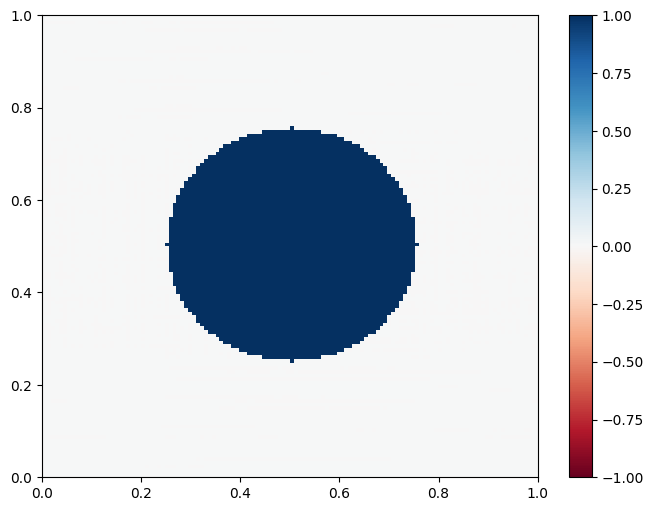

In [20]:
Heatmap(sample['x'].cpu().detach().numpy()[2, 0, ...])

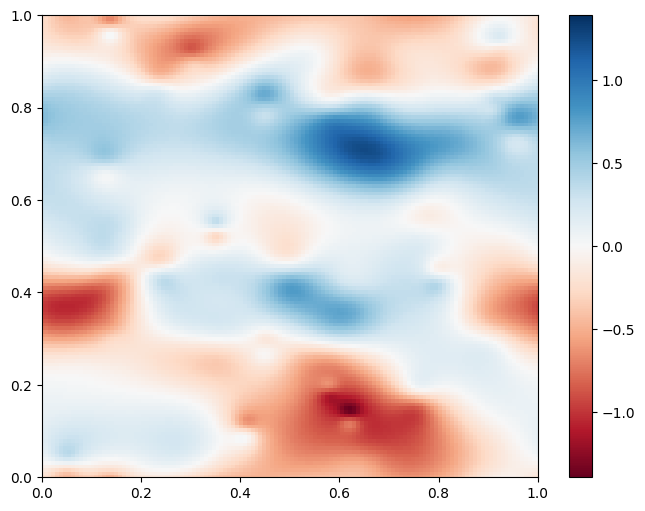

In [21]:
Heatmap(sample['x'].cpu().detach().numpy()[1, 0, ...])

In [3]:
import cv2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm

plt.rcParams['animation.ffmpeg_path'] = '/usr/bin/ffmpeg'
plt.rcParams['savefig.bbox'] = 'tight'

import torch.nn as nn
from torchvision import transforms

# CMAP = "viridis" # RdBu_r # Reds
CMAP = cm.viridis
CMAP.set_bad('white')

def pyplot_animate(pred: torch.Tensor, ref_sol: torch.Tensor, mask: np.ndarray, forcings: torch.Tensor = None, 
                   comp: int = 0, diff_with_initial = False, location: str = None, title: str = '', t_val_max: int = 36,
                   mode: str = 'gif', name: str = ''):
    print('Shapes in input for pyplot_animate ', pred.shape, ' vs ', ref_sol.shape)
    import matplotlib.animation as animation
    fig, ax = plt.subplots()

    ref_sol = ref_sol.permute(1, 0, 2, 3)
    print(f'Got to animate: pred {pred.shape}, ref_sol {ref_sol.shape}')
    ref = 0
    print('shape of parsed part:')
    if diff_with_initial:
        norm_data = colors.Normalize(vmin=min(np.min((pred.cpu().detach().numpy()[0, comp] * mask - 
                                                         np.repeat(pred.cpu().detach().numpy()[0, comp, ref:ref+1], 
                                                                   pred.shape[2], axis = 0) * mask)[ref:]), -1e-4), 
                                        # vcenter=0, 
                                        vmax=max(np.max((pred.cpu().detach().numpy()[0, comp] * mask -
                                                 np.repeat(pred.cpu().detach().numpy()[0, comp, ref:ref+1], 
                                                           pred.shape[2], axis = 0) * mask)[ref:]), 1e-4))
    else:
        norm_data = colors.Normalize(vmin=min(np.min(pred.cpu().detach().numpy()[0, comp] * mask), -1e-4), 
                                #    vcenter=0, 
                                   vmax=max(np.max(pred.cpu().detach().numpy()[0, comp] * mask), 1e-4))
    
    norm_err = colors.Normalize(vmin=min(np.min(np.abs(pred.cpu().detach().numpy()[0, comp][:t_val_max] * mask - 
                                                       ref_sol.cpu().detach().numpy()[comp][:t_val_max] * mask)), -1e-4),  #   * 0.5
                                                # /(np.abs(ref_sol.cpu().detach().numpy()[comp][:t_val_max]) + 1e-8)                                                          
                                #    vcenter=0, 
                                vmax=max(np.max(np.abs(pred.cpu().detach().numpy()[0, comp][:t_val_max] * mask - 
                                                       ref_sol.cpu().detach().numpy()[comp][:t_val_max] * mask)), 1e-4)) #  * 0.1
                                                    # /(np.abs(ref_sol.cpu().detach().numpy()[comp][:t_val_max]) + 1e-8)    

    current_directory = os.getcwd()

    loss = MSELoss()
    print(f'loss is {loss(pred, ref_sol.unsqueeze(0))}')


    diff_set = False
    imshows = None

    img = pred.cpu().detach().numpy()[0, comp, 0]
    ref_val = ref_sol.cpu().detach().numpy()[comp, 0]

    if forcings is None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    else:

        norm_forcings = colors.Normalize(vmin=min(np.min(forcings.cpu().detach().numpy() * mask), -1e-4),
                                #    vcenter=0, 
                                     vmax=max(np.max(forcings.cpu().detach().numpy() * mask), 1e-4))

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
        frc_img = forcings.cpu().detach().numpy()[0, 0, 0]


    ax1.set_title('Prediction')
    ax2.set_title('Error, absolute. value')
    if forcings is not None:
        ax3.set_title('Forcings')

    # if forcings is None:

    fig.suptitle(f'Component {comp+1}, time {0}')

    zero_thrs = 1e-6
    mask_err = (torch.abs(ref_sol[comp, 1, ...]) > zero_thrs).detach().numpy()

    im1 = ax1.imshow(img * mask, norm=norm_data, cmap=CMAP) #   interpolation='bilinear' cv2.GaussianBlur((img),(1, 3),0)
    im2 = ax2.imshow((img - ref_val), norm=norm_err, cmap=CMAP) # /(np.abs(ref_val) + 1e-8) , interpolation='bilinear'
    # cv2.GaussianBlur((img - ref_val),(1, 3),0)
    # print(np.std(img * mask), np.std(np.abs(img - ref_val) * mask_err))
    
    plt.colorbar(im1, ax=ax1, orientation='vertical') # imshows, 
    plt.colorbar(im2, ax=ax2, orientation='vertical') # imshows,   

    if forcings is not None:
        im3 = ax3.imshow(frc_img * mask, norm=norm_forcings, cmap=CMAP, interpolation='bilinear') # , interpolation='bilinear'
        plt.colorbar(im3, ax=ax3, orientation='vertical') # imshows,    

    def update(frame):
        # mask_err = (torch.abs(ref_sol[comp, frame+1, ...]) > zero_thrs).detach().numpy()
        
        img = pred.cpu().detach().numpy()[0, comp, frame]
        ref_val = ref_sol.cpu().detach().numpy()[comp, frame]
        if forcings is not None:
            frc_img = forcings.cpu().detach().numpy()[0, 0, frame]

        fig.suptitle(f'Component {comp+1}, time {frame+6}')
        # image2 = cv2.GaussianBlur((255 - image2),(9, 9),0)

        im1.set_array(np.ma.masked_array(cv2.GaussianBlur((img),(1, 3),0), 1-mask))

        # im1.set_array(np.ma.masked_array(img, 1-mask))
        im2.set_array(np.ma.masked_array(np.abs(img - ref_val), 1-mask)) # /(np.abs(ref_val) + 1e-8)
        # im2.set_array(np.ma.masked_array(cv2.GaussianBlur(np.abs(img - ref_val),(1, 3),0), 1-mask)) # /(np.abs(ref_val) + 1e-8)
        
        if forcings is not None:
            im3.set_array(np.ma.masked_array(frc_img, 1-mask)) # 
            return im1, im2, im3
        else:
            return im1, im2 #fig, (ax1, ax2)

        # plt.show()



    ani = animation.FuncAnimation(fig=fig, func=update, frames=pred.shape[2], interval=90)

    if mode == 'gif':
        writer = animation.PillowWriter(fps=5, metadata=dict(artist='Me'), bitrate=1800)
        filename = f'component_{comp}_{name}.gif'
        ani.save(os.path.join(current_directory, location, filename), writer=writer, dpi = 300)
        print(f'saved as gif into {os.path.join(current_directory, location, filename)}')
    else:
        filename = f'component_{comp}_{name}.mp4'
        ani.save(os.path.join(current_directory, location, filename), dpi = 300)
        print(f'saved as mp4 into {os.path.join(current_directory, location, filename)}')

Shapes in input for pyplot_animate  torch.Size([1, 2, 21, 128, 128])  vs  torch.Size([21, 2, 128, 128])
Got to animate: pred torch.Size([1, 2, 21, 128, 128]), ref_sol torch.Size([2, 21, 128, 128])
shape of parsed part:
loss is 0.2492242157459259
saved as mp4 into /home/mikemaslyaev/Documents/FNOFound/experiments/pics/component_0_cats_lno_old.mp4
Shapes in input for pyplot_animate  torch.Size([1, 2, 21, 128, 128])  vs  torch.Size([21, 2, 128, 128])
Got to animate: pred torch.Size([1, 2, 21, 128, 128]), ref_sol torch.Size([2, 21, 128, 128])
shape of parsed part:
loss is 0.2492242157459259
saved as mp4 into /home/mikemaslyaev/Documents/FNOFound/experiments/pics/component_1_cats_lno_old.mp4


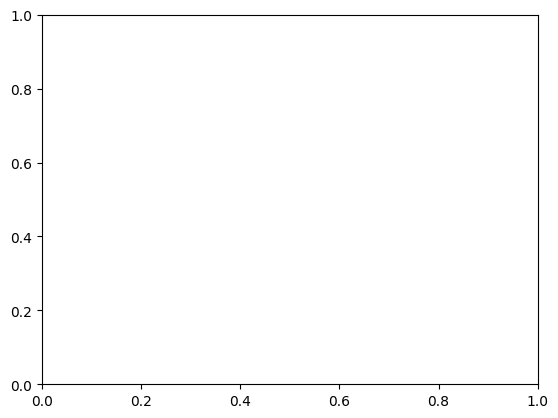

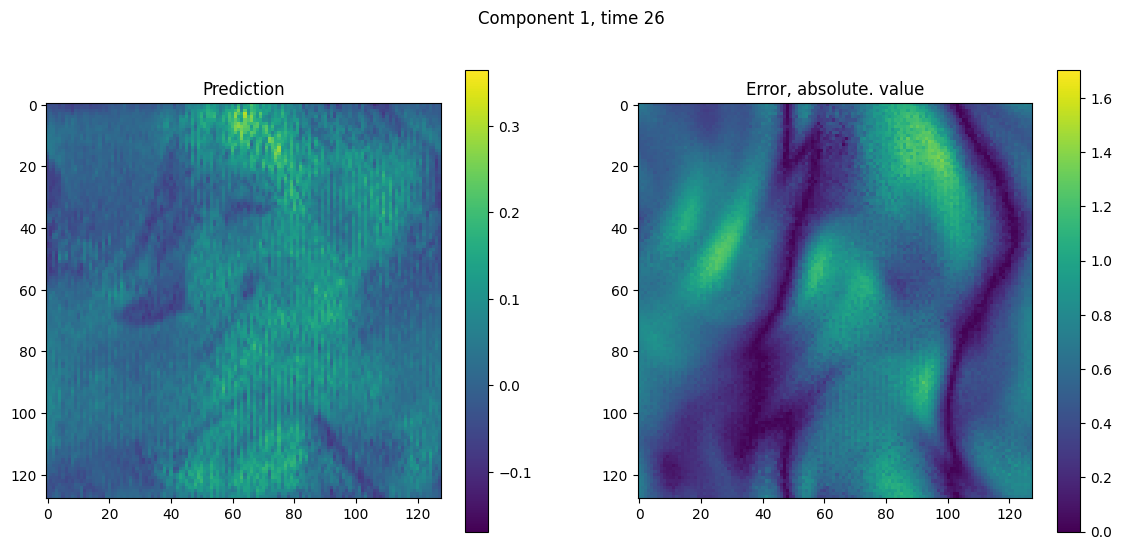

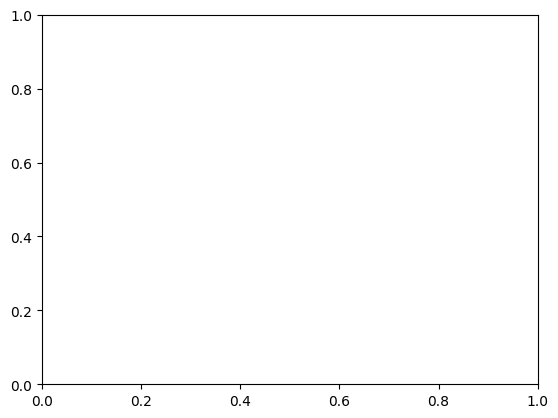

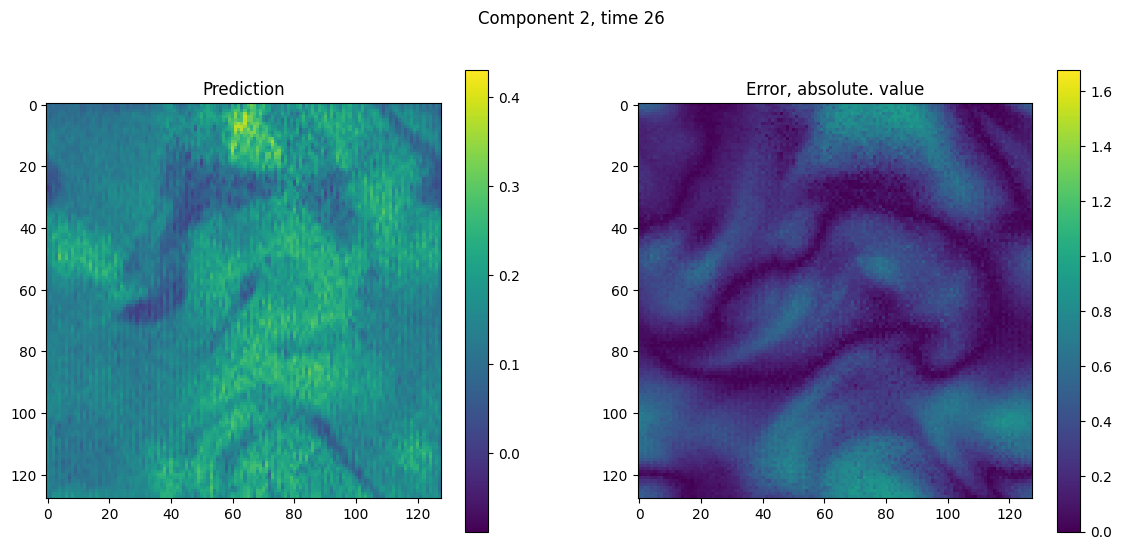

In [23]:
pyplot_animate(pred.cpu(), sample['y'][...].swapaxes(0, 1).cpu(), torch.ones_like(sample['y'][0, ...]).cpu().detach().numpy()[0, ...], 
               comp=0, forcings=None,
               diff_with_initial=False, location='/home/mikemaslyaev/Documents/FNOFound/experiments/pics', mode="mp4", name = 'cats_lno_old')
pyplot_animate(pred.cpu(), sample['y'][...].swapaxes(0, 1).cpu(), torch.ones_like(sample['y'][0, ...]).cpu().detach().numpy()[0, ...], 
               comp=1, forcings=None,
               diff_with_initial=False, location='/home/mikemaslyaev/Documents/FNOFound/experiments/pics', mode="mp4", name = 'cats_lno_old')

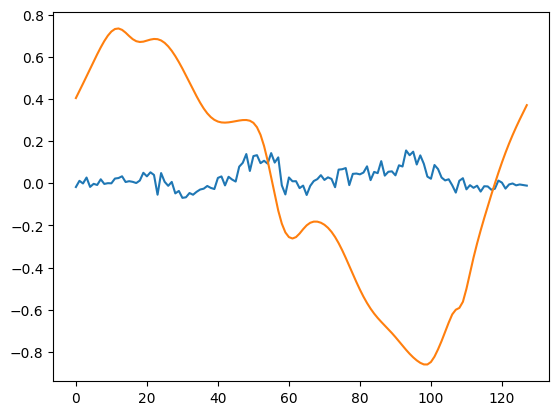

In [24]:
plt.plot(pred[0, 0, 10, 60, :].cpu().detach().numpy())
plt.plot(sample['y'][0, 10, 60, :].cpu().detach().numpy())


In [179]:
xx, yy = torch.linspace(0, 10, 100), torch.linspace(0, 10, 100)

In [180]:
X, Y = torch.meshgrid(xx, yy, indexing='ij')

In [188]:
z = 1 * torch.exp(- torch.pow(X - 5, 2) / 8. - torch.pow(Y - 5, 2) / 8.)

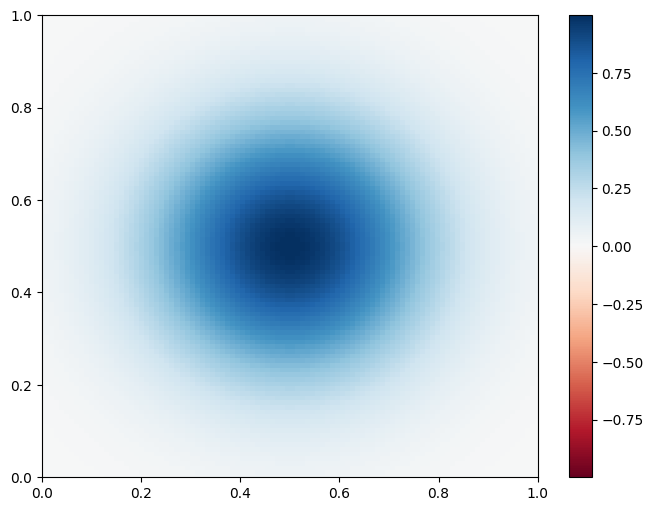

In [190]:
Heatmap(torch.fft.irfft2(torch.fft.rfft2(z)).detach().numpy())

In [1]:
import torch
import numpy as np
import tensordict as td

def syncSuffle(*input: torch.Tensor):
    n_samples = input[0].shape[0]
    for tensor in input:
        assert tensor.shape[0] == n_samples, f'Mismatching numbers of samples: {n_samples} vs {tensor.shape[0]}!'

    for i in range(0, input[0].shape[0]):
        j = np.random.randint(0, input[0].shape[0])
        for tensor_idx in range(len(input)):
            temp = input[tensor_idx][i].clone()
            input[tensor_idx][i] = input[tensor_idx][j].clone()
            input[tensor_idx][j] = temp
    
    return input

In [7]:
a = torch.linspace(0, 10, 11); b = torch.linspace(0, 10, 11)
a = a[:, None].expand((-1, a.shape[0])).clone()
b = b[:, None].expand((-1, b.shape[0])).clone()

a_ = td.MemoryMappedTensor.from_tensor(a)
b_ = td.MemoryMappedTensor.from_tensor(b)

In [3]:
a.shape

torch.Size([11, 11])

In [10]:
a_

MemoryMappedTensor([[ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.],
                    [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
                    [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
                    [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.],
                    [ 7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.],
                    [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
                    [ 4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.],
                    [ 8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.],
                    [ 9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.],
                    [ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.],
                    [10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.]])

In [37]:
a[:, 0]

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [9]:
a_, b_ = syncSuffle(a_, b_)

In [11]:
a_, b_

(MemoryMappedTensor([[ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.],
                     [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
                     [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
                     [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.],
                     [ 7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.],
                     [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
                     [ 4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.],
                     [ 8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.],
                     [ 9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.],
                     [ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.],
                     [10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.]]),
 MemoryMappedTensor([[ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.],
                     [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 

In [12]:
[i for i in range(3, 0, -1)]

[3, 2, 1]

In [149]:
class FourierHFLoss(object):
    def __init__(self, dims: List[int] = [3, 4]):
        self._dims = dims
        self._fourier_dim = len(dims)
        
    def __call__(self, pred: torch.Tensor, target: torch.Tensor, *args, **kwargs):
        error = target - pred
        
        error = torch.fft.fftn(error, dim = [pred.ndim - i for i in range(self._fourier_dim, 0, -1)])
        error = torch.pow(error, 2)

        hf_lim = min(15, int(pred.shape[-1]//2))
        
        Nxs = pred.shape[-self._fourier_dim:]
        Lxs = [1.] * self._fourier_dim
        xs = [torch.arange(Nx//2) for Nx in Nxs]
        XXs = torch.meshgrid(*xs, indexing = 'ij')
        mask = (torch.sqrt(torch.add(*[torch.pow(xx, 2) for xx in XXs])) >= hf_lim).to(int).to(pred.device)

        for ax_idx, dim in enumerate(self._dims):
            error = torch.swapaxes(error, axis0 = 0, axis1 = dim)
            error = error[:int(Nxs[ax_idx]//2), ...]
            error = torch.swapaxes(error, axis0 = 0, axis1 = dim)

        return torch.norm(error * mask) / (pred.shape[0] * pred.shape[1] * pred.shape[2] * torch.count_nonzero(mask))

In [150]:
loss = FourierHFLoss()

In [151]:
err_fft = loss(torch.ones((1, 2, 32, 128, 128)), torch.zeros((1, 2, 32, 128, 128)))

In [155]:
torch.add(*[err_fft, err_fft])

tensor(0.)

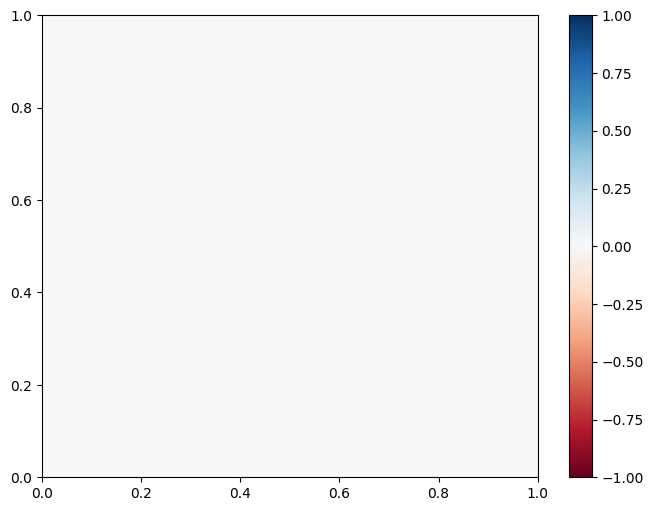

In [145]:
Heatmap(np.abs(err_fft[0, 0, 10, :5, :5].detach().numpy()), interval=[-1, 1])

In [37]:
np.sqrt(63**2 + 63**2)

89.09545442950498

In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42    

plt.rcParams["figure.figsize"] = (5.5, 9.5)

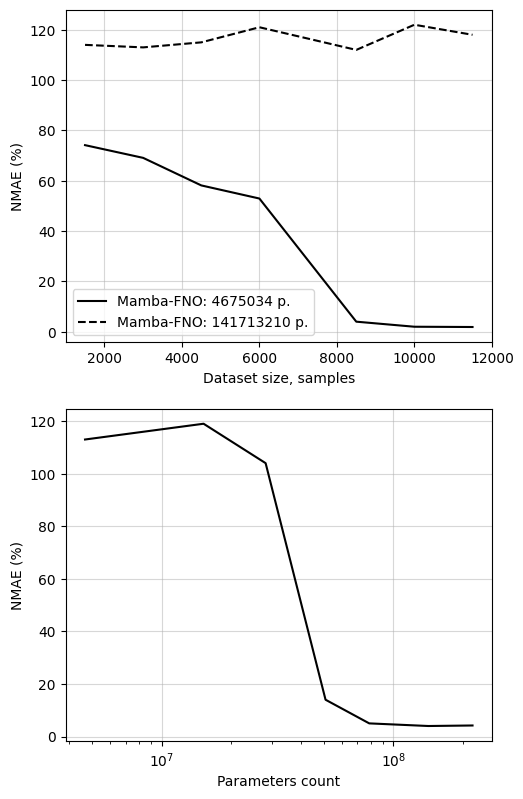

In [8]:
x1 = [1500, 3000, 4500, 6000, 8500, 10000, 11500]
y11 = [74.156, 69.1, 58.155, 52.94, 4.01, 2., 1.89]
y12 = [114., 113., 115., 121., 112., 122., 118.]
fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot(x1, y11, color = 'k', label = 'Mamba-FNO: 4675034 p.')
ax1.plot(x1, y12, '--', color = 'k', label = 'Mamba-FNO: 141713210 p.')
ax1.legend()
ax1.grid(alpha=0.5)
ax1.set_xlabel('Dataset size, samples')

# ax1.set_yscale('log')
ax1.set_ylabel('NMAE (%)')

x2 = [4675034, 15183439, 28130776, 51022186, 78761644, 141713210, 219825864]
y2 = [113., 119., 104., 14., 5., 4., 4.2]


ax2.plot(x2, y2, color = 'k')
ax2.grid(alpha=0.5)
ax2.set_xscale('log')
ax2.set_xlabel('Parameters count')
ax2.set_ylabel('NMAE (%)')
plt.savefig("scaling.pdf", bbox_inches='tight')

# plt.xlabel('Dataset size, samples')
# plt.ylabel('Relative L1 metric')

In [3]:
import tempfile

tf = tempfile.NamedTemporaryFile()
tf.name

'/tmp/tmpbgy2qb6m'

In [2]:
tf.close()

In [6]:
from tensordict import MemoryMappedTensor
import torch

In [11]:
tnsr = torch.ones((10, 10, 64, 64))
# with tempfile.NamedTemporaryFile() as file:
memmap_tensor = MemoryMappedTensor.from_tensor(tnsr, filename='/tmp/tmpo22doznm1')


In [12]:
memmap_tensor.filename

'/tmp/tmpo22doznm1'

In [13]:
import time

In [19]:
int(time.time()) % 100000

79743

In [33]:
import torch
from tensordict import TensorDict

td = TensorDict({'a': torch.zeros(30, 5, 20, 128, 128)}, batch_size=[30])
tdm = td.memmap_('/home/mikemaslyaev/Documents/FNOFound/backup/memmap_td')

In [38]:
type(tdm)

tensordict._td.TensorDict

In [37]:
tdm[0]['a'].clone()

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         ...,

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 